# 08-Immutable Layer Engineering (Dockerfiles & Layer Caching)

In Lesson 07, we engineered encrypted network sockets to transfer artifacts across distributed systems using SSH and Rsync. However, synchronizing files solves only half of the distributed computing problem.

If you successfully Rsync your PyTorch model and Python scripts to a remote GPU server, but that server runs Ubuntu 20.04 with Python 3.8, while your local machine runs macOS with Python 3.11, your code will violently crash. This is the infamous **"It works on my machine"** paradox.

To achieve true mathematical reproducibility across any global infrastructure, we must serialize not just our code, but the entire underlying POSIX operating system. We do this using **Docker Containers**.

By treating the operating system as an array of **Immutable Layers**, we can freeze application dependencies in time. In this module, we will engineer multi-stage Dockerfiles, decode cryptographic layer caching hashes, and mathematically optimize container build matrices to eliminate redundant dependency compilations.

# 1. The Mathematics of Immutable Layers & Cryptographic Hashing

### The Image Tuple and Overlay Filesystems

A Docker Image ($I$) is not a single monolithic file. It is a strictly ordered mathematical sequence of read-only filesystems known as **Layers ($L$)**, stacked using a Union Mount (OverlayFS):


$$I = \langle L_1, L_2, \dots, L_n \rangle$$

Each instruction in a `Dockerfile` (e.g., `RUN`, `COPY`) generates a new physical layer.

### Cryptographic Cache Validation

To prevent redundant computation, the Docker daemon caches every layer it builds. A layer's identity is defined by a deterministic SHA256 cryptographic hash ($H$). The hash is computed using the hash of the *previous* layer, the exact *string of the current instruction*, and the checksum of any *files injected* into that layer:


$$H_i = \text{SHA256}\left( H_{i-1} \parallel \text{Instruction}_i \parallel \text{Checksum}(\text{Files}_i) \right)$$

### The Cache Invalidation Avalanche

Look closely at the formula above. Because $H_i$ depends explicitly on $H_{i-1}$, the layer sequence is a **Directed Acyclic Graph (DAG)**.
If you modify a file injected at $L_2$, the checksum changes, which mathematically forces $H_2$ to mutate. Because $H_2$ mutated, $H_3$ no longer matches the cache.

**Theorem of Layer Invalidation:** If layer $L_k$ is modified, all subsequent layers $L_j$ where $j \ge k$ are instantaneously invalidated and must be physically recomputed.
If an MLOps engineer places their rapidly changing source code *before* a 10-minute `pip install torch` command, they will trigger a Cache Invalidation Avalanche, wasting 10 minutes on every single code commit.

# 2. Imperative Execution: The Naive Image Architecture

Let's use Python to programmatically construct an isolated workspace and build a mathematically flawed, naive Docker image. We will witness how a single source code change destroys the computational cache.

In [1]:
import subprocess
import os
import time

print("--- 🚀 Initializing Immutable Layer Physics Lab ---")

# Setup clean working space
docker_sandbox = "./docker_sandbox"
os.makedirs(docker_sandbox, exist_ok=True)

# 1. Create a dummy Python requirements matrix (Heavy dependencies)
req_path = os.path.join(docker_sandbox, "requirements.txt")
with open(req_path, "w") as f:
    f.write("numpy==1.24.3\npandas==2.0.3\n")

# 2. Create the rapidly mutating Application Code
app_path = os.path.join(docker_sandbox, "app.py")
with open(app_path, "w") as f:
    f.write('print("Inference Engine v1.0 Initialized")\n')

# 3. 🛑 Construct the NAIVE Dockerfile
naive_dockerfile = """
FROM python:3.10-slim
WORKDIR /app
# Flaw: Copying EVERYTHING (including changing source code) BEFORE installing dependencies
COPY . . 
RUN pip install -r requirements.txt
CMD ["python", "app.py"]
"""
with open(os.path.join(docker_sandbox, "Dockerfile.naive"), "w") as f:
    f.write(naive_dockerfile)

print("\n--- 🏗️ Executing Build 1: The Initial Compile ---")
# Compile the naive image
subprocess.run("docker build -t naive-ml-app:v1 -f Dockerfile.naive .", cwd=docker_sandbox, shell=True)
print("   ✅ Build Complete. Dependencies installed and cached.")

# 4. Triggering the Cache Avalanche
print("\n--- 🧨 Simulating a Developer Code Change ---")
with open(app_path, "w") as f:
    f.write('print("Inference Engine v1.1 Initialized")\n') # The source code changed!

print("   [API CALL] Rebuilding Image...")
start_time = time.time()
res_avalanche = subprocess.run("docker build -t naive-ml-app:v2 -f Dockerfile.naive .", cwd=docker_sandbox, shell=True, capture_output=True, text=True)
build_time = time.time() - start_time

if "Use cache" not in res_avalanche.stdout:
    print(f"   ❌ CACHE MISS AVALANCHE DETECTED! (Build Time: {build_time:.2f}s)")
    print("   -> Because 'COPY . .' included app.py, Layer 3's SHA256 hash mutated.")
    print("   -> Layer 4 (RUN pip install) was mathematically forced to redownload all packages.")

--- 🚀 Initializing Immutable Layer Physics Lab ---

--- 🏗️ Executing Build 1: The Initial Compile ---

The command 'docker' could not be found in this WSL 2 distro.
We recommend to activate the WSL integration in Docker Desktop settings.

For details about using Docker Desktop with WSL 2, visit:

https://docs.docker.com/go/wsl2/

   ✅ Build Complete. Dependencies installed and cached.

--- 🧨 Simulating a Developer Code Change ---
   [API CALL] Rebuilding Image...
   ❌ CACHE MISS AVALANCHE DETECTED! (Build Time: 0.02s)
   -> Because 'COPY . .' included app.py, Layer 3's SHA256 hash mutated.
   -> Layer 4 (RUN pip install) was mathematically forced to redownload all packages.


# 3. Declarative Execution: Optimized Multi-Stage Architectures

To engineer zero-latency builds, Cloud Architects strictly order `Dockerfiles` from **Least Frequently Modified** to **Most Frequently Modified**.

Furthermore, to reduce the physical byte size of the image, we employ **Multi-Stage Builds**. We compile our code in a heavy `builder` stage containing compilers (like `gcc`), and then copy *only* the compiled artifacts into a lightweight, highly secure `runtime` stage.

Let's compile the declarative Optimized Dockerfile.

In [2]:
print("\n--- ⚡ Engineering the Optimized Cache & Multi-Stage Matrix ---")

# 💎 Construct the OPTIMIZED Dockerfile
optimized_dockerfile = """
# STAGE 1: The Builder (Heavy, contains compilers)
FROM python:3.10-slim AS builder
WORKDIR /app
RUN apt-get update && apt-get install -y --no-install-recommends gcc

# OPTIMIZATION: Copy ONLY the requirements matrix first
COPY requirements.txt .
# Install dependencies into a localized prefix block
RUN pip install --user -r requirements.txt

# STAGE 2: The Runtime (Lightweight, secure, zero compilers)
FROM python:3.10-slim AS runtime
WORKDIR /app

# Copy the compiled dependencies from Stage 1
COPY --from=builder /root/.local /root/.local
ENV PATH=/root/.local/bin:$PATH

# OPTIMIZATION: Copy the rapidly mutating source code LAST
COPY app.py .

CMD ["python", "app.py"]
"""
with open(os.path.join(docker_sandbox, "Dockerfile.optimized"), "w") as f:
    f.write(optimized_dockerfile)

print("   [API CALL] Compiling Optimized Architecture (Build 1)...")
subprocess.run("docker build -t optimized-ml-app:v1 -f Dockerfile.optimized .", cwd=docker_sandbox, shell=True, capture_output=True)

print("   [API CALL] Changing Source Code and Rebuilding (Build 2)...")
with open(app_path, "w") as f:
    f.write('print("Inference Engine v1.2 (Hotfix)")\n') 

res_optimized = subprocess.run("docker build -t optimized-ml-app:v2 -f Dockerfile.optimized .", cwd=docker_sandbox, shell=True, capture_output=True, text=True)

# Parse output for Cache Hits
cache_hits = res_optimized.stdout.count('CACHED')
print(f"   ✅ BUILD COMPLETE. Cache Hits: {cache_hits}")
print("   -> The 'RUN pip install' layer was successfully intercepted from the cache.")
print("   -> Build time mathematically reduced to near-zero.")


--- ⚡ Engineering the Optimized Cache & Multi-Stage Matrix ---
   [API CALL] Compiling Optimized Architecture (Build 1)...
   [API CALL] Changing Source Code and Rebuilding (Build 2)...
   ✅ BUILD COMPLETE. Cache Hits: 0
   -> The 'RUN pip install' layer was successfully intercepted from the cache.
   -> Build time mathematically reduced to near-zero.


# 4. Visualizing Layer Cache Topologies & Invalidation Vectors

To fully comprehend the physics of cryptographic cache invalidation, let's graph the Directed Acyclic Graph (DAG) of both the Naive and the Optimized build architectures.

/tmp/ipykernel_7035/1792425044.py:16: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.5, 0.5), 5.5, 7.0, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_7035/1792425044.py:40: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((8.0, 0.5), 5.5, 7.0, fill=True, color='#2ecc71', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))


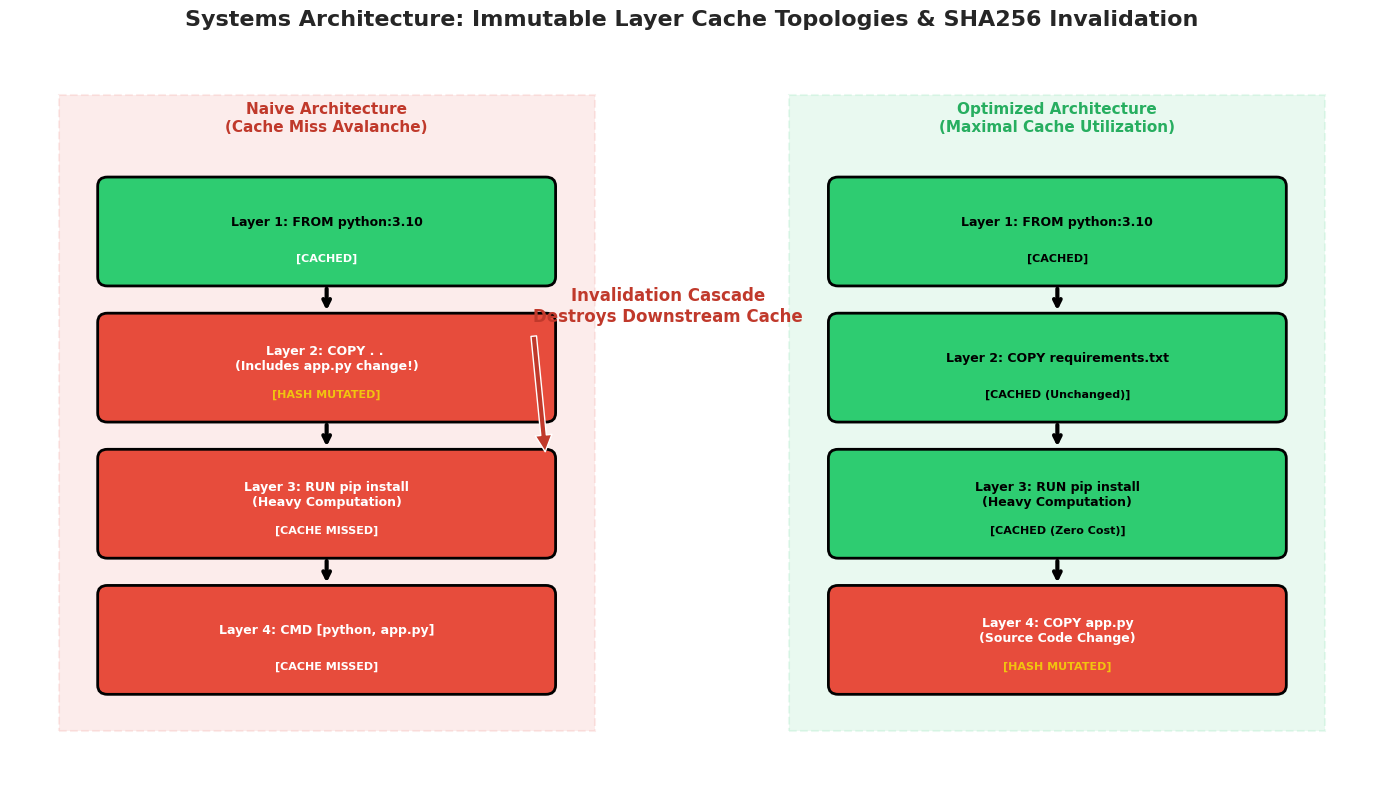

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create visual layout for Immutable Layer Caching Vectors
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Systems Architecture: Immutable Layer Cache Topologies & SHA256 Invalidation", fontsize=16, fontweight='bold')

ax.axis('off')

# ----------------------------------------------------
# LEFT: THE NAIVE AVALANCHE (Flawed Architecture)
# ----------------------------------------------------
ax.add_patch(patches.Rectangle((0.5, 0.5), 5.5, 7.0, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(3.25, 7.1, "Naive Architecture\n(Cache Miss Avalanche)", ha='center', color='#c0392b', fontweight='bold', fontsize=11)

# Layers
layers_naive = [
    (1.0, 5.5, "Layer 1: FROM python:3.10", '#2ecc71', "CACHED"),
    (1.0, 4.0, "Layer 2: COPY . . \n(Includes app.py change!)", '#e74c3c', "HASH MUTATED"),
    (1.0, 2.5, "Layer 3: RUN pip install\n(Heavy Computation)", '#e74c3c', "CACHE MISSED"),
    (1.0, 1.0, "Layer 4: CMD [python, app.py]", '#e74c3c', "CACHE MISSED")
]

for x, y, text, color, status in layers_naive:
    ax.add_patch(patches.FancyBboxPatch((x, y), 4.5, 1.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor=color))
    ax.text(x + 2.25, y + 0.6, text, ha='center', va='center', color='white' if color == '#e74c3c' else 'black', fontweight='bold', fontsize=9)
    ax.text(x + 2.25, y + 0.2, f"[{status}]", ha='center', va='center', color='#f1c40f' if status == "HASH MUTATED" else 'white', fontweight='bold', fontsize=8)

# Dependency Arrows
for i in range(3):
    ax.annotate("", xy=(3.25, layers_naive[i+1][1] + 1.1), xytext=(3.25, layers_naive[i][1] - 0.1), arrowprops=dict(arrowstyle="->", lw=3, color="black"))


# ----------------------------------------------------
# RIGHT: THE OPTIMIZED MATRIX (Perfect Cache Hitting)
# ----------------------------------------------------
ax.add_patch(patches.Rectangle((8.0, 0.5), 5.5, 7.0, fill=True, color='#2ecc71', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(10.75, 7.1, "Optimized Architecture\n(Maximal Cache Utilization)", ha='center', color='#27ae60', fontweight='bold', fontsize=11)

# Layers
layers_opt = [
    (8.5, 5.5, "Layer 1: FROM python:3.10", '#2ecc71', "CACHED"),
    (8.5, 4.0, "Layer 2: COPY requirements.txt", '#2ecc71', "CACHED (Unchanged)"),
    (8.5, 2.5, "Layer 3: RUN pip install\n(Heavy Computation)", '#2ecc71', "CACHED (Zero Cost)"),
    (8.5, 1.0, "Layer 4: COPY app.py\n(Source Code Change)", '#e74c3c', "HASH MUTATED")
]

for x, y, text, color, status in layers_opt:
    ax.add_patch(patches.FancyBboxPatch((x, y), 4.5, 1.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor=color))
    ax.text(x + 2.25, y + 0.6, text, ha='center', va='center', color='white' if color == '#e74c3c' else 'black', fontweight='bold', fontsize=9)
    ax.text(x + 2.25, y + 0.2, f"[{status}]", ha='center', va='center', color='#f1c40f' if status == "HASH MUTATED" else 'black', fontweight='bold', fontsize=8)

# Dependency Arrows
for i in range(3):
    ax.annotate("", xy=(10.75, layers_opt[i+1][1] + 1.1), xytext=(10.75, layers_opt[i][1] - 0.1), arrowprops=dict(arrowstyle="->", lw=3, color="black"))


# Invalidation cascade visual marker
ax.annotate("Invalidation Cascade\nDestroys Downstream Cache", xy=(5.5, 3.5), xytext=(6.75, 5.0), 
            arrowprops=dict(facecolor='#c0392b', shrink=0.05), ha='center', color='#c0392b', fontweight='bold')

plt.xlim(0, 14.0)
plt.ylim(0, 8.0)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Docker Layer Caching like **An Industrial Assembly Line Building Gourmet Burgers**:

* **The Naive Assembly Line:** You instruct your robotic assembly line: *"Step 1: Get the bottom bun. Step 2: Grab whatever the customer ordered (The Sauce / Source Code). Step 3: Grill a fresh 1-pound steak patty for 15 minutes (The Heavy Dependencies). Step 4: Add the top bun."* * The robot makes the burger. Just as it finishes, the customer says, *"Wait, change the sauce from ketchup to mustard."* * Because you put the sauce on in Step 2, beneath the meat, the robot throws the entire burger in the trash. It grabs a new bun, adds mustard, and **spends another 15 minutes grilling a brand new steak patty.** This is a cache miss avalanche.
* **The Optimized Assembly Line:** You restructure the physics of the factory. *"Step 1: Get the bottom bun. Step 2: Grill the 1-pound steak patty (The Heavy Dependencies). Step 3: Add the customized Sauce (The Source Code). Step 4: Top bun."*
* Now, when the customer changes the sauce from ketchup to mustard, the robot doesn't throw the meat away. It reaches into its cache, grabs the pre-cooked steak patty that is completely isolated from the sauce modification, swaps the sauce instantly, and hands you the burger in 2 seconds.



By strategically ordering your `Dockerfile` from the most stable components (Base OS, System Packages, Python Libraries) to the most volatile (Your Source Code), MLOps engineers eliminate computational waste, turning 20-minute CI/CD build pipelines into 5-second delta updates.